# 🏷️ KREAM 프리미엄 등급 예측 모델링

## 전체 파이프라인 요약
1. **Step 1**: KMeans로 `premium_ratio`를 클러스터링 → 타겟 라벨 생성
2. **Step 2**: XGBoost 분류 모델 학습 (Model 1: Baseline / Model 2: Refined)
3. **Step 3**: TH4 후처리로 소수 클래스(class 4) Recall 보완
4. **Step 4**: 4개 모델 성능 비교 시각화 및 예측 리포트 생성

### ✅ 주요 수정 사항
| 항목 | 수정 내용 |
|------|----------|
| 절대경로 | 상단 `INPUT_CSV` 변수 하나만 수정하면 되도록 통일 |
| K 선택 근거 | K 범위 설정 이유 + Elbow/Silhouette 판단 기준 명시 |
| VIF 기준 | `VIF_TH = 10` 기준 명시 및 주석 추가 |
| 하이퍼파라미터 | 하드코딩 제거 → 상단 CONFIG 딕셔너리로 통합 |
| TH4 누수 방지 | val split에 `reset_index` 추가, groups 인덱스 정렬 |
| 코드 중복 | 셀 [13] 중복 import 제거, 셀 순서 정리 |

In [1]:
# ============================================================
# ✅ [경로 설정] 여기만 본인 환경에 맞게 수정하세요
# ============================================================
import os

# 방법 1: 직접 경로 지정
INPUT_CSV = r"C:\Users\lg\min_python\KHUDA\KHUDA_9_ML\Toy_project\outputs\06_modeling_dataset.csv"

# 방법 2: 이 노트북 파일 기준 상대경로 (권장)
# BASE_DIR = os.path.dirname(os.path.abspath('__file__'))  # 노트북 위치
# INPUT_CSV = os.path.join(BASE_DIR, '..', 'outputs', '06_modeling_dataset.csv')

print(f"[INFO] INPUT_CSV = {INPUT_CSV}")
print(f"[INFO] 파일 존재 여부: {os.path.exists(INPUT_CSV)}")

[INFO] INPUT_CSV = C:\Users\lg\min_python\KHUDA\KHUDA_9_ML\Toy_project\outputs\06_modeling_dataset.csv
[INFO] 파일 존재 여부: True


In [2]:
# ============================================================
# ✅ [전역 설정] 하이퍼파라미터를 한 곳에서 관리
#    → 모델 재학습 시 이 셀만 수정하면 됩니다
# ============================================================
CONFIG = {
    # KMeans
    "k_final": 5,           # 최종 클러스터 수 (Step 1 Elbow/Silhouette 결과 기반)
    "k_range": (2, 7),      # 탐색 범위: 2~6 (스니커즈 시장 프리미엄을 5구간으로 나누는 게 해석상 적절)

    # XGBoost
    "xgb_n_estimators": 500,
    "xgb_learning_rate": 0.05,
    "xgb_max_depth": 6,
    "xgb_random_state": 42,

    # Feature Selection
    "vif_threshold": 10,    # VIF >= 10이면 다중공선성 심각 → 제거 (일반적인 기준)
    "top_k_non_color": 12,  # color 피처 제외 비색상 피처 최대 선택 수

    # TH4 탐색
    "th4_grid": (0.05, 0.50, 10),  # (시작, 끝, 스텝 수)
    "th4_default": 0.10,            # TH4 탐색 실패 시 fallback 값

    # 공통
    "random_state": 42,
    "test_size": 0.2,
    "rolling_n": 5,         # recent_avg_premium 윈도우 크기
}

print("[CONFIG]")
for k, v in CONFIG.items():
    print(f"  {k}: {v}")

[CONFIG]
  k_final: 5
  k_range: (2, 7)
  xgb_n_estimators: 500
  xgb_learning_rate: 0.05
  xgb_max_depth: 6
  xgb_random_state: 42
  vif_threshold: 10
  top_k_non_color: 12
  th4_grid: (0.05, 0.5, 10)
  th4_default: 0.1
  random_state: 42
  test_size: 0.2
  rolling_n: 5


In [3]:
# ============================================================
# ✅ [라이브러리 임포트] 한 곳에서 통합 관리
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupShuffleSplit
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score,
    classification_report, confusion_matrix, silhouette_score
)
from statsmodels.stats.outliers_influence import variance_inflation_factor
from xgboost import XGBClassifier, plot_importance

print("✅ 라이브러리 임포트 완료")

✅ 라이브러리 임포트 완료


---
## Step 1. 최적의 K 찾기 (KMeans 클러스터링)

### 왜 KMeans로 타겟을 만드나?
- `premium_ratio`(프리미엄 비율)는 연속형 변수이지만, **명시적인 등급 라벨이 존재하지 않음**
- KMeans로 분포를 자동 분할 → 의미 있는 등급(낮음/보통/높음/...)으로 이산화

### K 탐색 범위를 2~6으로 설정한 이유
- K=2: 너무 단순 (프리미엄/비프리미엄 2구간)
- K=5 or 6: 스니커즈 시장에서 의미 있게 해석 가능한 최대 등급 수
- K=7 이상: 클러스터가 지나치게 세분화되어 각 라벨의 의미 해석이 어려워짐
- **판단 기준**: Elbow Method(관성)와 Silhouette Score를 **함께** 보고 결정

In [4]:
# 데이터 로드
df = pd.read_csv(INPUT_CSV)

# 결측치 제거 및 클러스터링 대상 피처(log_premium_ratio) 추출
df_clean = df.dropna(subset=['premium_ratio']).copy()

# log 변환 (음수 premium_ratio 대비: -0.99로 하한 클립 후 log1p)
df_clean['log_premium_ratio'] = np.log1p(df_clean['premium_ratio'].clip(lower=-0.99))
X_cluster = df_clean[['log_premium_ratio']]

# 스케일링
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

print(f"[INFO] 전체 데이터 수: {len(df_clean):,}")
print(f"[INFO] premium_ratio 분포: min={df_clean['premium_ratio'].min():.3f}, "
      f"max={df_clean['premium_ratio'].max():.3f}, "
      f"mean={df_clean['premium_ratio'].mean():.3f}")

[INFO] 전체 데이터 수: 165,139
[INFO] premium_ratio 분포: min=-0.721, max=20.164, mean=0.300


In [5]:
# ============================================================
# K 탐색: Elbow Method + Silhouette Score
# ============================================================
k_start, k_end = CONFIG["k_range"]
k_range = range(k_start, k_end)
inertias = []
silhouette_scores = []

for k in k_range:
    kmeans_tmp = KMeans(n_clusters=k, random_state=CONFIG["random_state"], n_init=10)
    labels = kmeans_tmp.fit_predict(X_scaled)
    inertias.append(kmeans_tmp.inertia_)
    score = silhouette_score(X_scaled, labels, sample_size=5000, random_state=CONFIG["random_state"])
    silhouette_scores.append(score)
    print(f"   ▶ [K={k}] 실루엣 점수: {score:.4f}  |  관성: {kmeans_tmp.inertia_:.2f}")

best_k_sil = k_start + int(np.argmax(silhouette_scores))
print(f"\n[INFO] 실루엣 점수 기준 최적 K = {best_k_sil}")
print(f"[INFO] 최종 선택 K = {CONFIG['k_final']} "
      f"(도메인 해석 + Elbow 판단 종합)")

   ▶ [K=2] 실루엣 점수: 0.5949  |  관성: 66172.47
   ▶ [K=3] 실루엣 점수: 0.5587  |  관성: 34221.58
   ▶ [K=4] 실루엣 점수: 0.5538  |  관성: 20040.75
   ▶ [K=5] 실루엣 점수: 0.5343  |  관성: 12785.83
   ▶ [K=6] 실루엣 점수: 0.5489  |  관성: 8483.12

[INFO] 실루엣 점수 기준 최적 K = 2
[INFO] 최종 선택 K = 5 (도메인 해석 + Elbow 판단 종합)


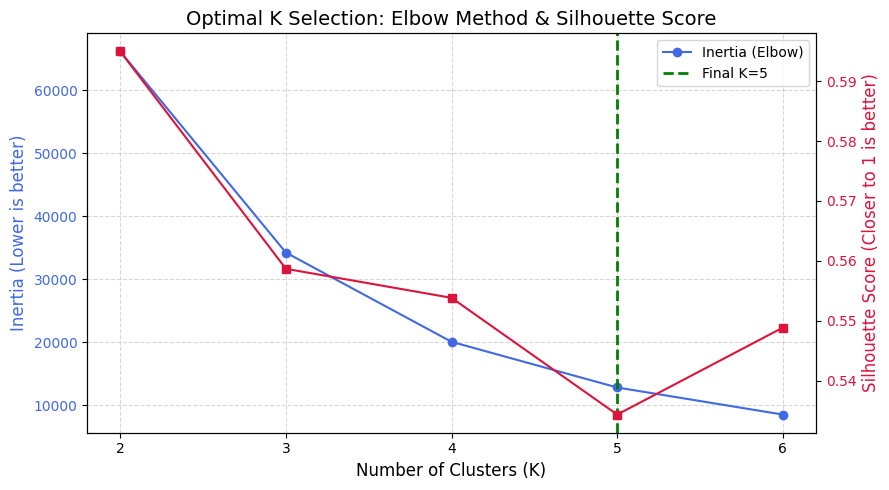

In [6]:
# 결과 시각화
fig, ax1 = plt.subplots(figsize=(9, 5))

ax1.plot(k_range, inertias, marker='o', color='royalblue', label='Inertia (Elbow)')
ax1.set_xlabel('Number of Clusters (K)', fontsize=12)
ax1.set_ylabel('Inertia (Lower is better)', color='royalblue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='royalblue')
ax1.set_xticks(list(k_range))
ax1.grid(True, linestyle='--', alpha=0.5)

ax2 = ax1.twinx()
ax2.plot(k_range, silhouette_scores, marker='s', color='crimson', label='Silhouette Score')
ax2.set_ylabel('Silhouette Score (Closer to 1 is better)', color='crimson', fontsize=12)
ax2.tick_params(axis='y', labelcolor='crimson')

# 최종 선택 K 표시
ax1.axvline(x=CONFIG['k_final'], color='green', linestyle='--', linewidth=2, label=f'Final K={CONFIG["k_final"]}')
ax1.legend(loc='upper right')

plt.title('Optimal K Selection: Elbow Method & Silhouette Score', fontsize=14)
fig.tight_layout()
plt.show()

---
## Step 2. 모델 학습 및 Test-set 적용

### 데이터 분리 전략
- `GroupShuffleSplit(group=product_id)`: **같은 상품이 train/test에 동시에 들어가지 않도록** 제품 단위 분리
- KMeans는 **train으로만 fit** → test는 predict만 (라벨 누수 방지)
- 라벨 순서(0=최저 프리미엄 ~ 4=최고 프리미엄)는 **train 기준 premium_ratio 평균으로 고정**

In [7]:
df = pd.read_csv(INPUT_CSV)
df_clean = df.dropna(subset=['premium_ratio']).copy()

# 시간 순 정렬 (제품별 시계열 유지)
df_clean['trade_date_dt'] = pd.to_datetime(df_clean['trade_date'])
df_clean = df_clean.sort_values(['product_id', 'trade_date_dt']).reset_index(drop=True)

# ============================
# 1) Train/Test 분리 (제품 기준)
# ============================
groups = df_clean['product_id']
gss = GroupShuffleSplit(n_splits=1, test_size=CONFIG["test_size"], random_state=CONFIG["random_state"])
train_idx, test_idx = next(gss.split(df_clean, groups=groups))

train_df = df_clean.iloc[train_idx].copy()
test_df  = df_clean.iloc[test_idx].copy()

print(f"[INFO] Train 샘플: {len(train_df):,}  |  Test 샘플: {len(test_df):,}")
print(f"[INFO] Train 제품 수: {train_df['product_id'].nunique():,}  |  Test 제품 수: {test_df['product_id'].nunique():,}")

# ============================
# 2) KMeans 라벨링 (train fit → test predict)
# ============================
train_df['log_premium_ratio'] = np.log1p(train_df['premium_ratio'].clip(lower=-0.99))
test_df['log_premium_ratio']  = np.log1p(test_df['premium_ratio'].clip(lower=-0.99))

scaler_p = StandardScaler()
train_scaled = scaler_p.fit_transform(train_df[['log_premium_ratio']])
test_scaled  = scaler_p.transform(test_df[['log_premium_ratio']])

k_final = CONFIG["k_final"]
kmeans = KMeans(n_clusters=k_final, random_state=CONFIG["random_state"], n_init=10)
train_df['target_label'] = kmeans.fit_predict(train_scaled)
test_df['target_label']  = kmeans.predict(test_scaled)

# 라벨 순서(저→고 프리미엄) 매핑: train 기준으로 고정
order = train_df.groupby('target_label')['premium_ratio'].mean().sort_values().index
mapping = {old: new for new, old in enumerate(order)}
train_df['target_label'] = train_df['target_label'].map(mapping)
test_df['target_label']  = test_df['target_label'].map(mapping)

# 클래스별 프리미엄 평균 확인 (라벨 해석)
print("\n[라벨별 premium_ratio 평균 (train 기준)]")
print(train_df.groupby('target_label')['premium_ratio'].agg(['mean', 'count']).round(3))

df_clean = pd.concat([train_df, test_df]).sort_index().reset_index(drop=True)

# ============================
# 3) 피처 엔지니어링
# ============================
df_clean['release_date_dt'] = pd.to_datetime(df_clean['release_date'])
df_clean['days_since_release'] = (df_clean['trade_date_dt'] - df_clean['release_date_dt']).dt.days

n = CONFIG["rolling_n"]
df_clean[f'recent_avg_premium_{n}'] = (
    df_clean.groupby('product_id')['premium_ratio']
    .transform(lambda s: s.shift(1).rolling(window=n, min_periods=2).mean())
    .fillna(0)
)

df_clean['rolling_price_std'] = (
    df_clean.groupby('product_id')['current_price']
    .transform(lambda x: x.shift(1).rolling(window=7, min_periods=2).std())
    .fillna(0)
)

df_clean['trade_velocity'] = (
    df_clean.groupby('product_id')['trade_date_dt']
    .diff().dt.days.fillna(0)
    .transform(lambda x: x.shift(1).rolling(window=3, min_periods=1).sum())
    .fillna(0)
)

df_clean['log_release_price'] = np.log1p(df_clean['release_price'])
df_clean['log_google_trend_release'] = np.log1p(df_clean['google_trend_release'])
df_clean['log_google_trend_n_day'] = np.log1p(df_clean['google_trend_n_day'])
df_clean['trend_retention'] = df_clean['google_trend_n_day'] / (df_clean['google_trend_release'] + 1)

color_cols = [col for col in df_clean.columns if 'color_' in col]
features = [
    'log_release_price', 'is_collaboration', 'size', 'golden_size',
    'log_google_trend_release', 'log_google_trend_n_day', 'trend_retention',
    'rolling_price_std', 'trade_velocity', 'days_since_release', f'recent_avg_premium_{n}'
] + color_cols

X = df_clean[features]
y = df_clean['target_label']
groups = df_clean['product_id']

# 같은 split 유지
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print(f"\n[INFO] X_train shape: {X_train.shape}  |  X_test shape: {X_test.shape}")
print("[INFO] 클래스 분포 (train):")
print(y_train.value_counts().sort_index())

[INFO] Train 샘플: 125,207  |  Test 샘플: 39,932
[INFO] Train 제품 수: 91  |  Test 제품 수: 23

[라벨별 premium_ratio 평균 (train 기준)]
               mean  count
target_label              
0            -0.390  23678
1            -0.138  41180
2             0.277  39027
3             1.195  18362
4             7.175   2960

[INFO] X_train shape: (125207, 22)  |  X_test shape: (39932, 22)
[INFO] 클래스 분포 (train):
target_label
0    23678
1    41180
2    39027
3    18362
4     2960
Name: count, dtype: int64


In [8]:
# ============================
# 클래스 불균형 보정 (sample_weight)
# ============================
# 이유: 클래스별 샘플 수 차이가 크면 다수 클래스에 편향된 예측이 발생
# 방법: 'balanced' 모드 → 각 클래스 가중치 = 총 샘플 / (클래스 수 × 클래스 샘플 수)
classes = np.sort(y_train.unique())
cw = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight_dict = {int(c): float(w) for c, w in zip(classes, cw)}
sample_weight_train = y_train.map(class_weight_dict).values

print('[INFO] class_weight_dict =', class_weight_dict)

[INFO] class_weight_dict = {0: 1.0575808767632402, 1: 0.6080961631860127, 2: 0.6416429651267072, 3: 1.3637621174164034, 4: 8.459932432432433}


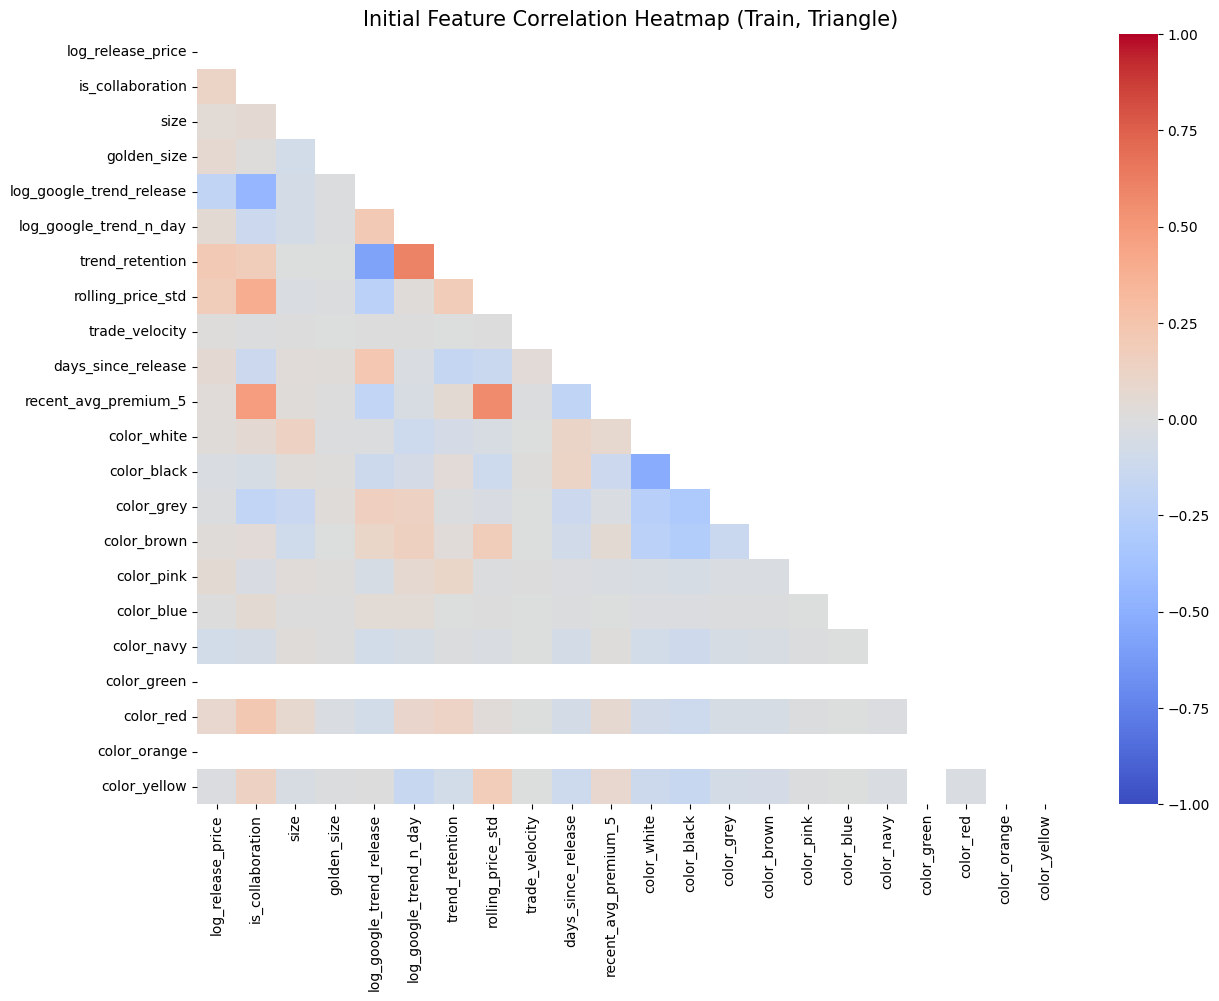

In [9]:
# 초기 피처 상관관계 히트맵 (Train 기준)
plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(X_train.corr(), dtype=bool))
sns.heatmap(X_train.corr(), mask=mask, annot=False, cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Initial Feature Correlation Heatmap (Train, Triangle)', fontsize=15)
plt.show()

---
## Model 1: Baseline XGBoost

### 하이퍼파라미터 선택 근거
| 파라미터 | 값 | 이유 |
|---------|-----|------|
| `n_estimators` | 500 | 과적합 없이 충분한 앙상블 크기 |
| `learning_rate` | 0.05 | 낮은 학습률 + 높은 트리 수 조합 (일반적인 안정 설정) |
| `max_depth` | 6 | XGBoost 기본값; 너무 깊으면 과적합 위험 |

> ⚠️ **주의**: 현재 파라미터는 경험적 기본값입니다. 실제 프로젝트에서는 Optuna/GridSearchCV로 최적화를 권장합니다.

In [10]:
# 첫번째 모델 학습 (전체 피처 사용)
xgb_base = XGBClassifier(
    n_estimators=CONFIG["xgb_n_estimators"],
    learning_rate=CONFIG["xgb_learning_rate"],
    max_depth=CONFIG["xgb_max_depth"],
    random_state=CONFIG["xgb_random_state"],
    eval_metric='mlogloss'
)
xgb_base.fit(X_train, y_train, sample_weight=sample_weight_train)
y_pred_base = xgb_base.predict(X_test)

print("=" * 60)
print(" [Model 1] Baseline 평가 결과")
print("=" * 60)
print(f"▶ Accuracy (정확도)  : {accuracy_score(y_test, y_pred_base):.4f}")
print(f"▶ F1-Score (Weighted): {f1_score(y_test, y_pred_base, average='weighted'):.4f}")
print(f"▶ F1-Score (Macro)   : {f1_score(y_test, y_pred_base, average='macro'):.4f}")
print(f"  └ Macro 선택 이유: 클래스 불균형 시 소수 클래스를 동등하게 반영")
print("\n[라벨별 상세 평가지표]")
print(classification_report(y_test, y_pred_base))

 [Model 1] Baseline 평가 결과
▶ Accuracy (정확도)  : 0.7956
▶ F1-Score (Weighted): 0.7934
▶ F1-Score (Macro)   : 0.7536
  └ Macro 선택 이유: 클래스 불균형 시 소수 클래스를 동등하게 반영

[라벨별 상세 평가지표]
              precision    recall  f1-score   support

           0       0.83      0.85      0.84      7321
           1       0.79      0.83      0.81     15141
           2       0.81      0.71      0.75     11041
           3       0.75      0.86      0.80      5499
           4       0.75      0.45      0.56       930

    accuracy                           0.80     39932
   macro avg       0.79      0.74      0.75     39932
weighted avg       0.80      0.80      0.79     39932



---
## TH4 임계값 튜닝

### 배경
- class 4(폭등)는 데이터가 매우 적어 기본 argmax 예측에서 Recall이 낮음
- **TH4 후처리**: `P(class=4) >= TH4`이면 강제로 class 4로 예측 → Recall 향상
- **Tradeoff**: Recall 올라가는 대신 Precision이 일부 낮아질 수 있음

### 누수 방지 설계
- TH4를 결정하는 validation set은 **test set과 완전히 분리된 train 내부 split**
- GroupShuffleSplit으로 제품 단위 누수도 방지

In [11]:
# ============================
# TH4 자동 튜닝
# - train 내부에서 GroupShuffleSplit으로 val 분리
# - val에서 찾은 TH4를 test에 적용 (test는 절대 참조 안 함)
# ============================

# train 내부를 한 번 더 group split (제품 단위 누수 방지)
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=CONFIG["random_state"])

# ✅ 수정: groups를 train_idx로 정확히 서브셋
groups_train = groups.iloc[train_idx].reset_index(drop=True)
X_train_reset = X_train.reset_index(drop=True)
y_train_reset = y_train.reset_index(drop=True)
sw_reset = sample_weight_train  # 이미 numpy array

tr2_idx, val_idx = next(gss2.split(X_train_reset, y_train_reset, groups=groups_train))

X_tr2, y_tr2 = X_train_reset.iloc[tr2_idx], y_train_reset.iloc[tr2_idx]
X_val, y_val = X_train_reset.iloc[val_idx], y_train_reset.iloc[val_idx]
sw_tr2 = sw_reset[tr2_idx]

# 임시 모델로 TH4 탐색 (test set 참조 없음)
xgb_tmp = XGBClassifier(
    n_estimators=CONFIG["xgb_n_estimators"],
    learning_rate=CONFIG["xgb_learning_rate"],
    max_depth=CONFIG["xgb_max_depth"],
    random_state=CONFIG["xgb_random_state"],
    eval_metric='mlogloss'
)
xgb_tmp.fit(X_tr2, y_tr2, sample_weight=sw_tr2)
proba_val = xgb_tmp.predict_proba(X_val)
pred_val = np.argmax(proba_val, axis=1)

th_start, th_end, th_steps = CONFIG["th4_grid"]
th_grid = np.round(np.linspace(th_start, th_end, th_steps), 2)
best_th4, best_f1 = None, -1

print("[TH4 탐색 결과]")
for th in th_grid:
    pred_th = np.where(proba_val[:, 4] >= th, 4, pred_val)
    f1m = f1_score(y_val, pred_th, average='macro')
    marker = " ← best" if f1m > best_f1 else ""
    print(f"  TH4={th:.2f} | val F1-macro={f1m:.4f}{marker}")
    if f1m > best_f1:
        best_f1 = f1m
        best_th4 = float(th)

print(f"\n[INFO] TH4 최적값: {best_th4} (val F1-macro: {best_f1:.4f})")

[TH4 탐색 결과]
  TH4=0.05 | val F1-macro=0.7127 ← best
  TH4=0.10 | val F1-macro=0.7079
  TH4=0.15 | val F1-macro=0.7075
  TH4=0.20 | val F1-macro=0.7052
  TH4=0.25 | val F1-macro=0.7036
  TH4=0.30 | val F1-macro=0.6984
  TH4=0.35 | val F1-macro=0.6894
  TH4=0.40 | val F1-macro=0.6820
  TH4=0.45 | val F1-macro=0.6759
  TH4=0.50 | val F1-macro=0.6655

[INFO] TH4 최적값: 0.05 (val F1-macro: 0.7127)


In [12]:
# ==========================================
# TH4 후처리: Model 1 (Baseline)
# ==========================================
TH4 = best_th4 if best_th4 is not None else CONFIG["th4_default"]
print(f"[INFO] 사용 TH4 = {TH4}")

proba_base = xgb_base.predict_proba(X_test)
y_pred_base_th = np.where(proba_base[:, 4] >= TH4, 4, y_pred_base)

print("=" * 60)
print(f" [Model 1 + TH4({TH4})] 평가 결과")
print("=" * 60)
print(f"▶ Accuracy (정확도)  : {accuracy_score(y_test, y_pred_base_th):.4f}")
print(f"▶ F1-Score (Weighted): {f1_score(y_test, y_pred_base_th, average='weighted'):.4f}")
print(f"▶ F1-Score (Macro)   : {f1_score(y_test, y_pred_base_th, average='macro'):.4f}")
print(classification_report(y_test, y_pred_base_th))

[INFO] 사용 TH4 = 0.05
 [Model 1 + TH4(0.05)] 평가 결과
▶ Accuracy (정확도)  : 0.7960
▶ F1-Score (Weighted): 0.7951
▶ F1-Score (Macro)   : 0.7727
              precision    recall  f1-score   support

           0       0.83      0.85      0.84      7321
           1       0.79      0.83      0.81     15141
           2       0.81      0.71      0.75     11041
           3       0.77      0.82      0.80      5499
           4       0.65      0.67      0.66       930

    accuracy                           0.80     39932
   macro avg       0.77      0.78      0.77     39932
weighted avg       0.80      0.80      0.80     39932



---
## Feature Selection (VIF + Feature Importance)

### 전략
1. **Feature Importance (Gain/Weight)**: XGBoost 내부 중요도 기준으로 상위 피처 우선 선택
2. **VIF (분산팽창지수)**: 다중공선성 제거
   - **VIF < 10**: 다중공선성 없음 → 채택
   - **VIF ≥ 10**: 다중공선성 심각 → 제거 (일반적 기준; Kutner et al., 2004)
3. **Color 피처**: 원핫 인코딩 특성상 VIF 적용이 부적절 → 통째로 포함

<Figure size 1000x800 with 0 Axes>

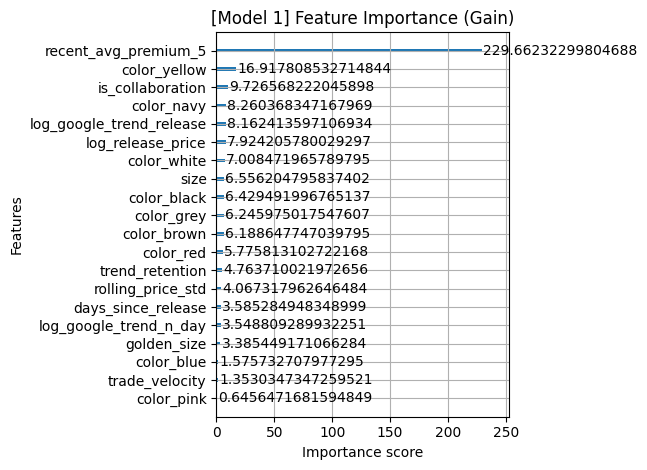

<Figure size 1000x800 with 0 Axes>

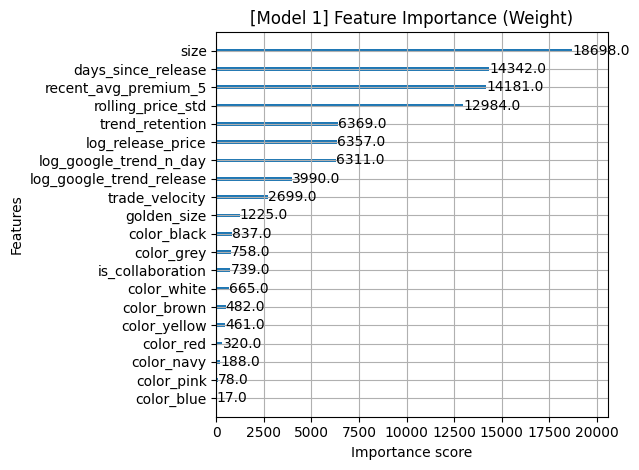

[INFO] 전체 피처: 22개  |  color: 11개  |  non-color: 11개
[INFO] VIF 기준: >= 10 이면 제거 (다중공선성 심각 기준)

--- 피처 선택 시작 (non-color, 중요도 순 + VIF 필터링) ---
  ✅ 채택: recent_avg_premium_5                (최상위 피처, VIF 계산 불필요)
  ✅ 채택: is_collaboration                    (VIF=1.38)
  ✅ 채택: log_google_trend_release            (VIF=1.20)
  ❌ 제외: log_release_price                   (VIF=208.14 ≥ 10, 다중공선성 높음)
  ❌ 제외: size                                (VIF=138.73 ≥ 10, 다중공선성 높음)
  ✅ 채택: trend_retention                     (VIF=5.59)
  ✅ 채택: rolling_price_std                   (VIF=2.17)
  ✅ 채택: days_since_release                  (VIF=1.43)
  ❌ 제외: log_google_trend_n_day              (VIF=859.80 ≥ 10, 다중공선성 높음)
  ✅ 채택: golden_size                         (VIF=2.04)
  ✅ 채택: trade_velocity                      (VIF=1.00)

⭐ 최종 선택 피처: non-color 8개 + color 11개

✅ X_train_final shape: (125207, 19)
✅ X_test_final  shape: (39932, 19)


In [13]:
# ==========================================
# Feature Importance 시각화 (Model 1)
# ==========================================
plt.figure(figsize=(10, 8))
plot_importance(xgb_base, importance_type='gain', title='[Model 1] Feature Importance (Gain)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
plot_importance(xgb_base, importance_type='weight', title='[Model 1] Feature Importance (Weight)')
plt.tight_layout()
plt.show()

# ==========================================
# VIF + 중요도 기반 피처 선택
# ==========================================
VIF_TH      = CONFIG["vif_threshold"]    # 10 이상이면 제거
TOP_K       = CONFIG["top_k_non_color"]
COLOR_PREFIX = "color_"

all_features    = list(X_train.columns)
color_features  = [c for c in all_features if c.startswith(COLOR_PREFIX)]
non_color_features = [c for c in all_features if c not in color_features]

print(f"[INFO] 전체 피처: {len(all_features)}개  |  color: {len(color_features)}개  |  non-color: {len(non_color_features)}개")
print(f"[INFO] VIF 기준: >= {VIF_TH} 이면 제거 (다중공선성 심각 기준)")

# 중요도 순 정렬
fi = pd.DataFrame({
    "f": all_features,
    "importance": xgb_base.feature_importances_
}).sort_values("importance", ascending=False)

fi_non_color = fi[fi["f"].isin(non_color_features)].reset_index(drop=True)

selected_non_color = []
print("\n--- 피처 선택 시작 (non-color, 중요도 순 + VIF 필터링) ---")

for f in fi_non_color["f"]:
    temp = selected_non_color + [f]
    if len(temp) > 1:
        vif = variance_inflation_factor(X_train[temp].values, len(temp) - 1)
        if vif < VIF_TH:
            selected_non_color.append(f)
            print(f"  ✅ 채택: {f:<35} (VIF={vif:.2f})")
        else:
            print(f"  ❌ 제외: {f:<35} (VIF={vif:.2f} ≥ {VIF_TH}, 다중공선성 높음)")
    else:
        selected_non_color.append(f)
        print(f"  ✅ 채택: {f:<35} (최상위 피처, VIF 계산 불필요)")

    if len(selected_non_color) >= TOP_K:
        print(f"  → TOP_K={TOP_K}개 도달, 탐색 종료")
        break

selected_features = selected_non_color + color_features

print("\n" + "=" * 60)
print(f"⭐ 최종 선택 피처: non-color {len(selected_non_color)}개 + color {len(color_features)}개")
print("=" * 60)

X_train_final = X_train[selected_features].copy()
X_test_final  = X_test[selected_features].copy()

print(f"\n✅ X_train_final shape: {X_train_final.shape}")
print(f"✅ X_test_final  shape: {X_test_final.shape}")

---
## Model 2: Refined XGBoost (선택된 피처로 재학습)

In [14]:
# 선택된 피처로 모델 재학습
xgb_final = XGBClassifier(
    n_estimators=CONFIG["xgb_n_estimators"],
    learning_rate=CONFIG["xgb_learning_rate"],
    max_depth=CONFIG["xgb_max_depth"],
    random_state=CONFIG["xgb_random_state"],
    eval_metric='mlogloss'
)
xgb_final.fit(X_train_final, y_train, sample_weight=sample_weight_train)
y_pred_final = xgb_final.predict(X_test_final)

print("=" * 60)
print(" [Model 2] Refined 평가 결과")
print("=" * 60)
print(f"▶ Accuracy (정확도)  : {accuracy_score(y_test, y_pred_final):.4f}")
print(f"▶ F1-Score (Weighted): {f1_score(y_test, y_pred_final, average='weighted'):.4f}")
print(f"▶ F1-Score (Macro)   : {f1_score(y_test, y_pred_final, average='macro'):.4f}")
print("\n[라벨별 상세 평가지표]")
print(classification_report(y_test, y_pred_final))

 [Model 2] Refined 평가 결과
▶ Accuracy (정확도)  : 0.7946
▶ F1-Score (Weighted): 0.7927
▶ F1-Score (Macro)   : 0.7392

[라벨별 상세 평가지표]
              precision    recall  f1-score   support

           0       0.83      0.78      0.81      7321
           1       0.77      0.86      0.81     15141
           2       0.80      0.75      0.78     11041
           3       0.83      0.80      0.81      5499
           4       0.70      0.38      0.49       930

    accuracy                           0.79     39932
   macro avg       0.79      0.71      0.74     39932
weighted avg       0.80      0.79      0.79     39932



In [15]:
# TH4 후처리: Model 2
proba_final = xgb_final.predict_proba(X_test_final)
y_pred_final_th = np.where(proba_final[:, 4] >= TH4, 4, y_pred_final)

print("=" * 60)
print(f" [Model 2 + TH4({TH4})] 평가 결과")
print("=" * 60)
print(f"▶ Accuracy (정확도)  : {accuracy_score(y_test, y_pred_final_th):.4f}")
print(f"▶ F1-Score (Weighted): {f1_score(y_test, y_pred_final_th, average='weighted'):.4f}")
print(f"▶ F1-Score (Macro)   : {f1_score(y_test, y_pred_final_th, average='macro'):.4f}")
print(classification_report(y_test, y_pred_final_th))

 [Model 2 + TH4(0.05)] 평가 결과
▶ Accuracy (정확도)  : 0.7897
▶ F1-Score (Weighted): 0.7902
▶ F1-Score (Macro)   : 0.7509
              precision    recall  f1-score   support

           0       0.83      0.78      0.81      7321
           1       0.77      0.86      0.81     15141
           2       0.80      0.75      0.78     11041
           3       0.87      0.71      0.78      5499
           4       0.50      0.70      0.58       930

    accuracy                           0.79     39932
   macro avg       0.75      0.76      0.75     39932
weighted avg       0.80      0.79      0.79     39932



---
## 4개 모델 성능 비교 시각화

In [16]:
# 모델별 예측 변수명 통일
pred_m1    = y_pred_base
pred_m1_th = y_pred_base_th
pred_m2    = y_pred_final
pred_m2_th = y_pred_final_th

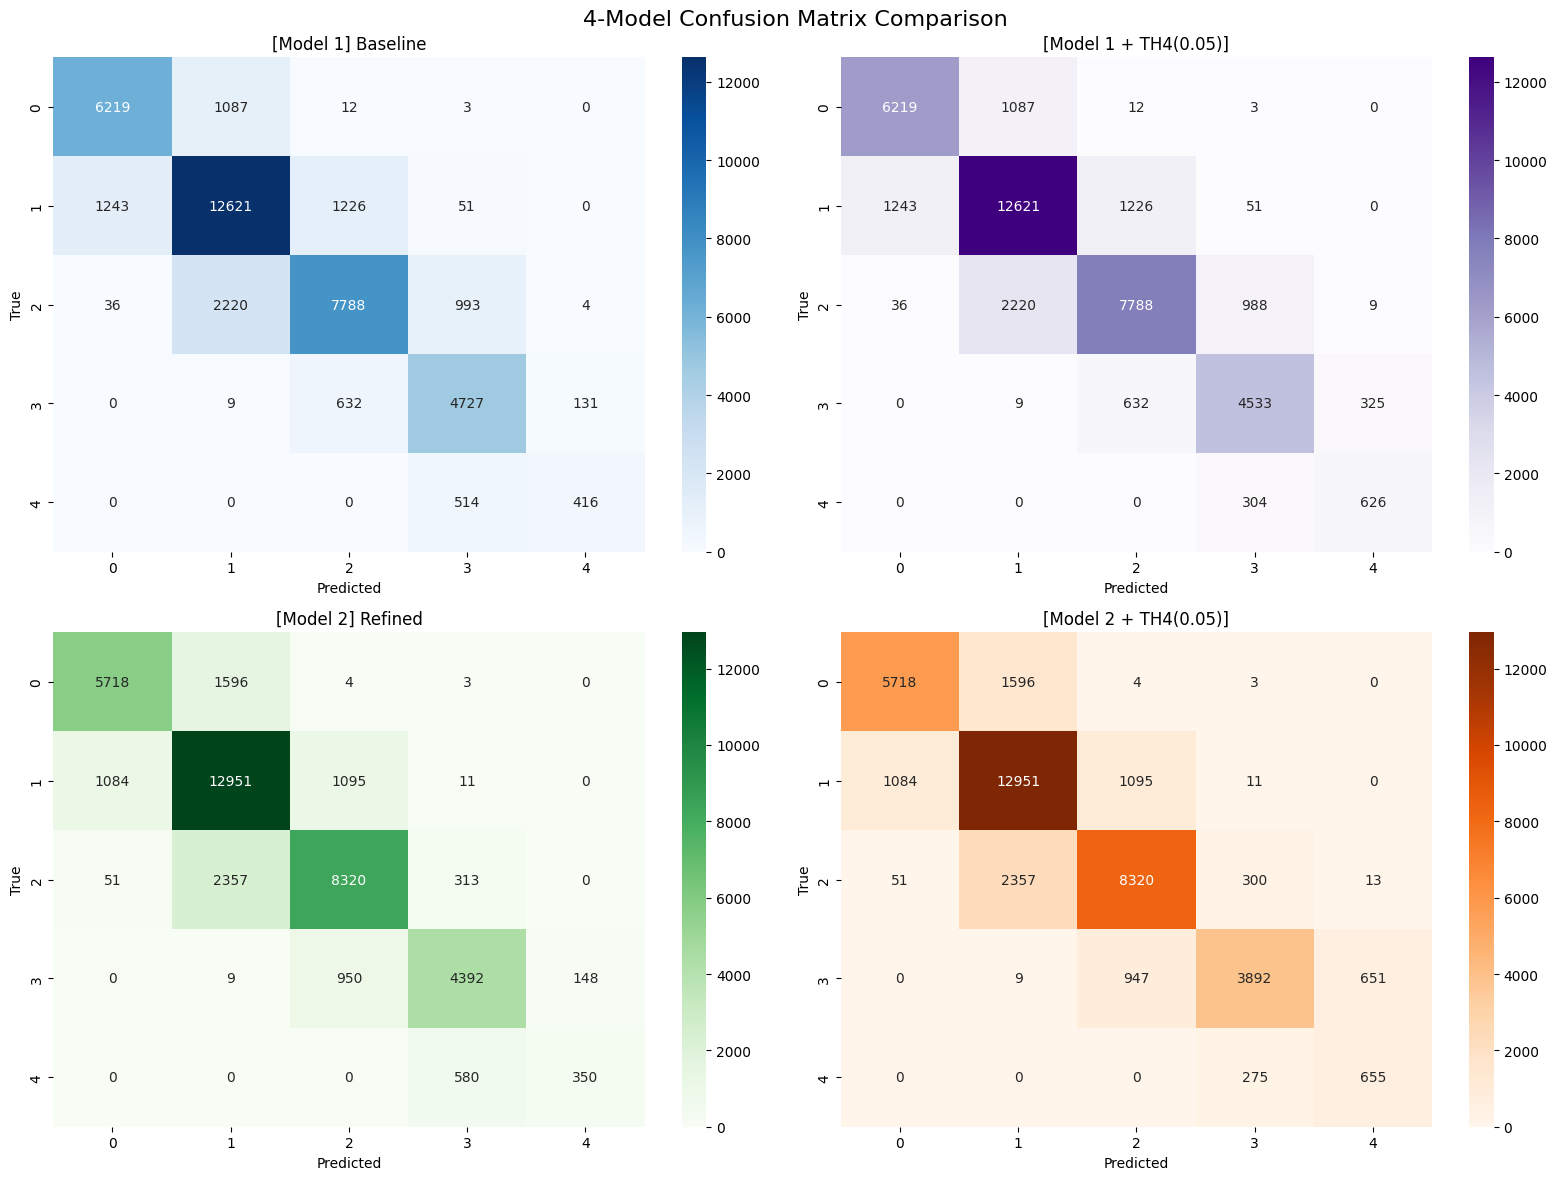

In [17]:
# Confusion Matrix 4개 비교
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.heatmap(confusion_matrix(y_test, pred_m1), annot=True, fmt='d', cmap='Blues', ax=axes[0, 0])
axes[0, 0].set_title('[Model 1] Baseline')

sns.heatmap(confusion_matrix(y_test, pred_m1_th), annot=True, fmt='d', cmap='Purples', ax=axes[0, 1])
axes[0, 1].set_title(f'[Model 1 + TH4({TH4})]')

sns.heatmap(confusion_matrix(y_test, pred_m2), annot=True, fmt='d', cmap='Greens', ax=axes[1, 0])
axes[1, 0].set_title('[Model 2] Refined')

sns.heatmap(confusion_matrix(y_test, pred_m2_th), annot=True, fmt='d', cmap='Oranges', ax=axes[1, 1])
axes[1, 1].set_title(f'[Model 2 + TH4({TH4})]')

for ax in axes.flatten():
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.suptitle('4-Model Confusion Matrix Comparison', fontsize=16)
plt.tight_layout()
plt.show()

In [18]:
# 성능표 (Accuracy / F1-macro / F1-weighted / Recall-macro)
results = []
for name, y_pred in [
    ("Model1",              pred_m1),
    (f"Model1+TH4({TH4})", pred_m1_th),
    ("Model2",              pred_m2),
    (f"Model2+TH4({TH4})", pred_m2_th),
]:
    results.append({
        "model"        : name,
        "accuracy"     : round(accuracy_score(y_test, y_pred), 4),
        "f1_macro"     : round(f1_score(y_test, y_pred, average="macro"), 4),
        "f1_weighted"  : round(f1_score(y_test, y_pred, average="weighted"), 4),
        "recall_macro" : round(recall_score(y_test, y_pred, average="macro"), 4),
    })

result_df = pd.DataFrame(results).sort_values("f1_macro", ascending=False).reset_index(drop=True)
print("[전체 모델 성능 비교 - f1_macro 내림차순]")
display(result_df)

[전체 모델 성능 비교 - f1_macro 내림차순]


,model,accuracy,f1_macro,f1_weighted,recall_macro
0,Model1+TH4(0.05),0.7960,0.7727,0.7951,0.7772
1,Model1,0.7956,0.7536,0.7934,0.7391
2,Model2+TH4(0.05),0.7897,0.7509,0.7902,0.7604
3,Model2,0.7946,0.7392,0.7927,0.7130


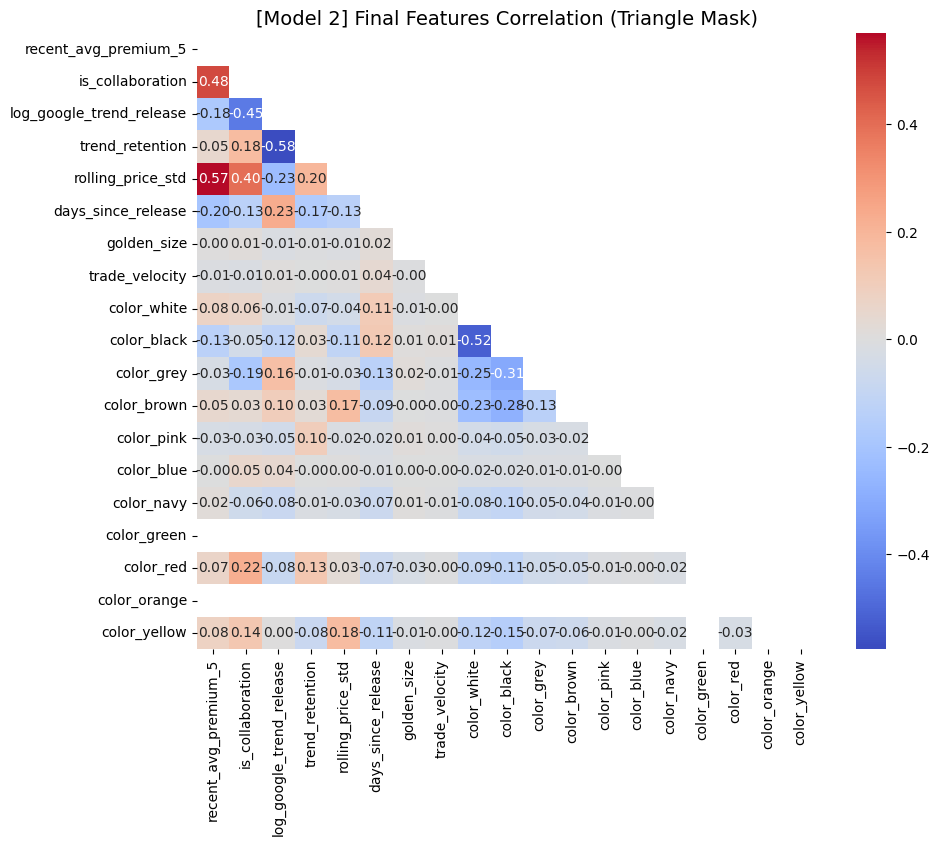

<Figure size 1000x600 with 0 Axes>

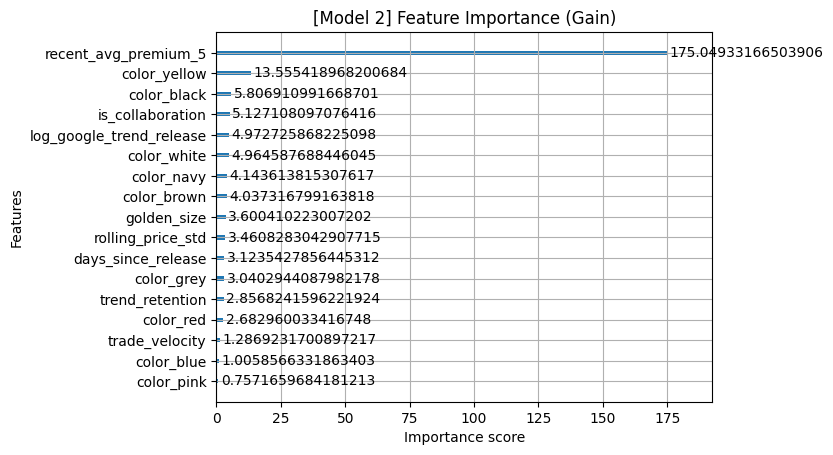

<Figure size 1000x600 with 0 Axes>

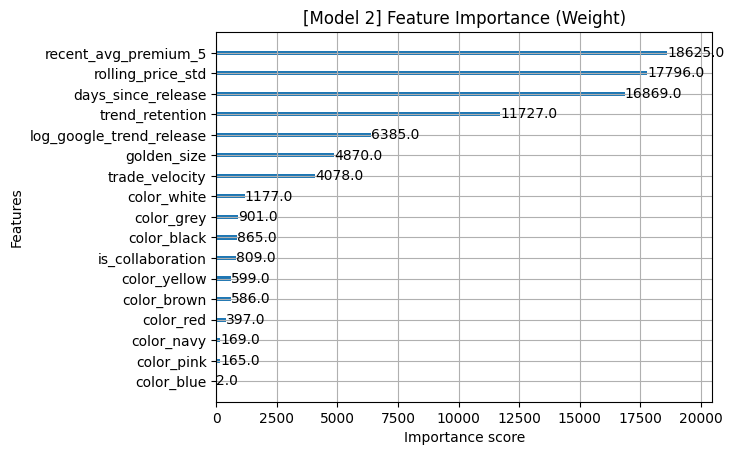

In [19]:
# 최종 피처 상관관계 히트맵 (Model 2 기준)
plt.figure(figsize=(10, 8))
mask_f = np.triu(np.ones_like(X_train_final.corr(), dtype=bool))
sns.heatmap(X_train_final.corr(), mask=mask_f, annot=True, cmap='coolwarm', center=0, fmt=".2f")
plt.title('[Model 2] Final Features Correlation (Triangle Mask)', fontsize=14)
plt.show()

# Model 2 Feature Importance
plt.figure(figsize=(10, 6))
plot_importance(xgb_final, importance_type='gain', title='[Model 2] Feature Importance (Gain)')
plt.show()

plt.figure(figsize=(10, 6))
plot_importance(xgb_final, importance_type='weight', title='[Model 2] Feature Importance (Weight)')
plt.show()

---
## 시각화 모아보기 (One-Page Report)

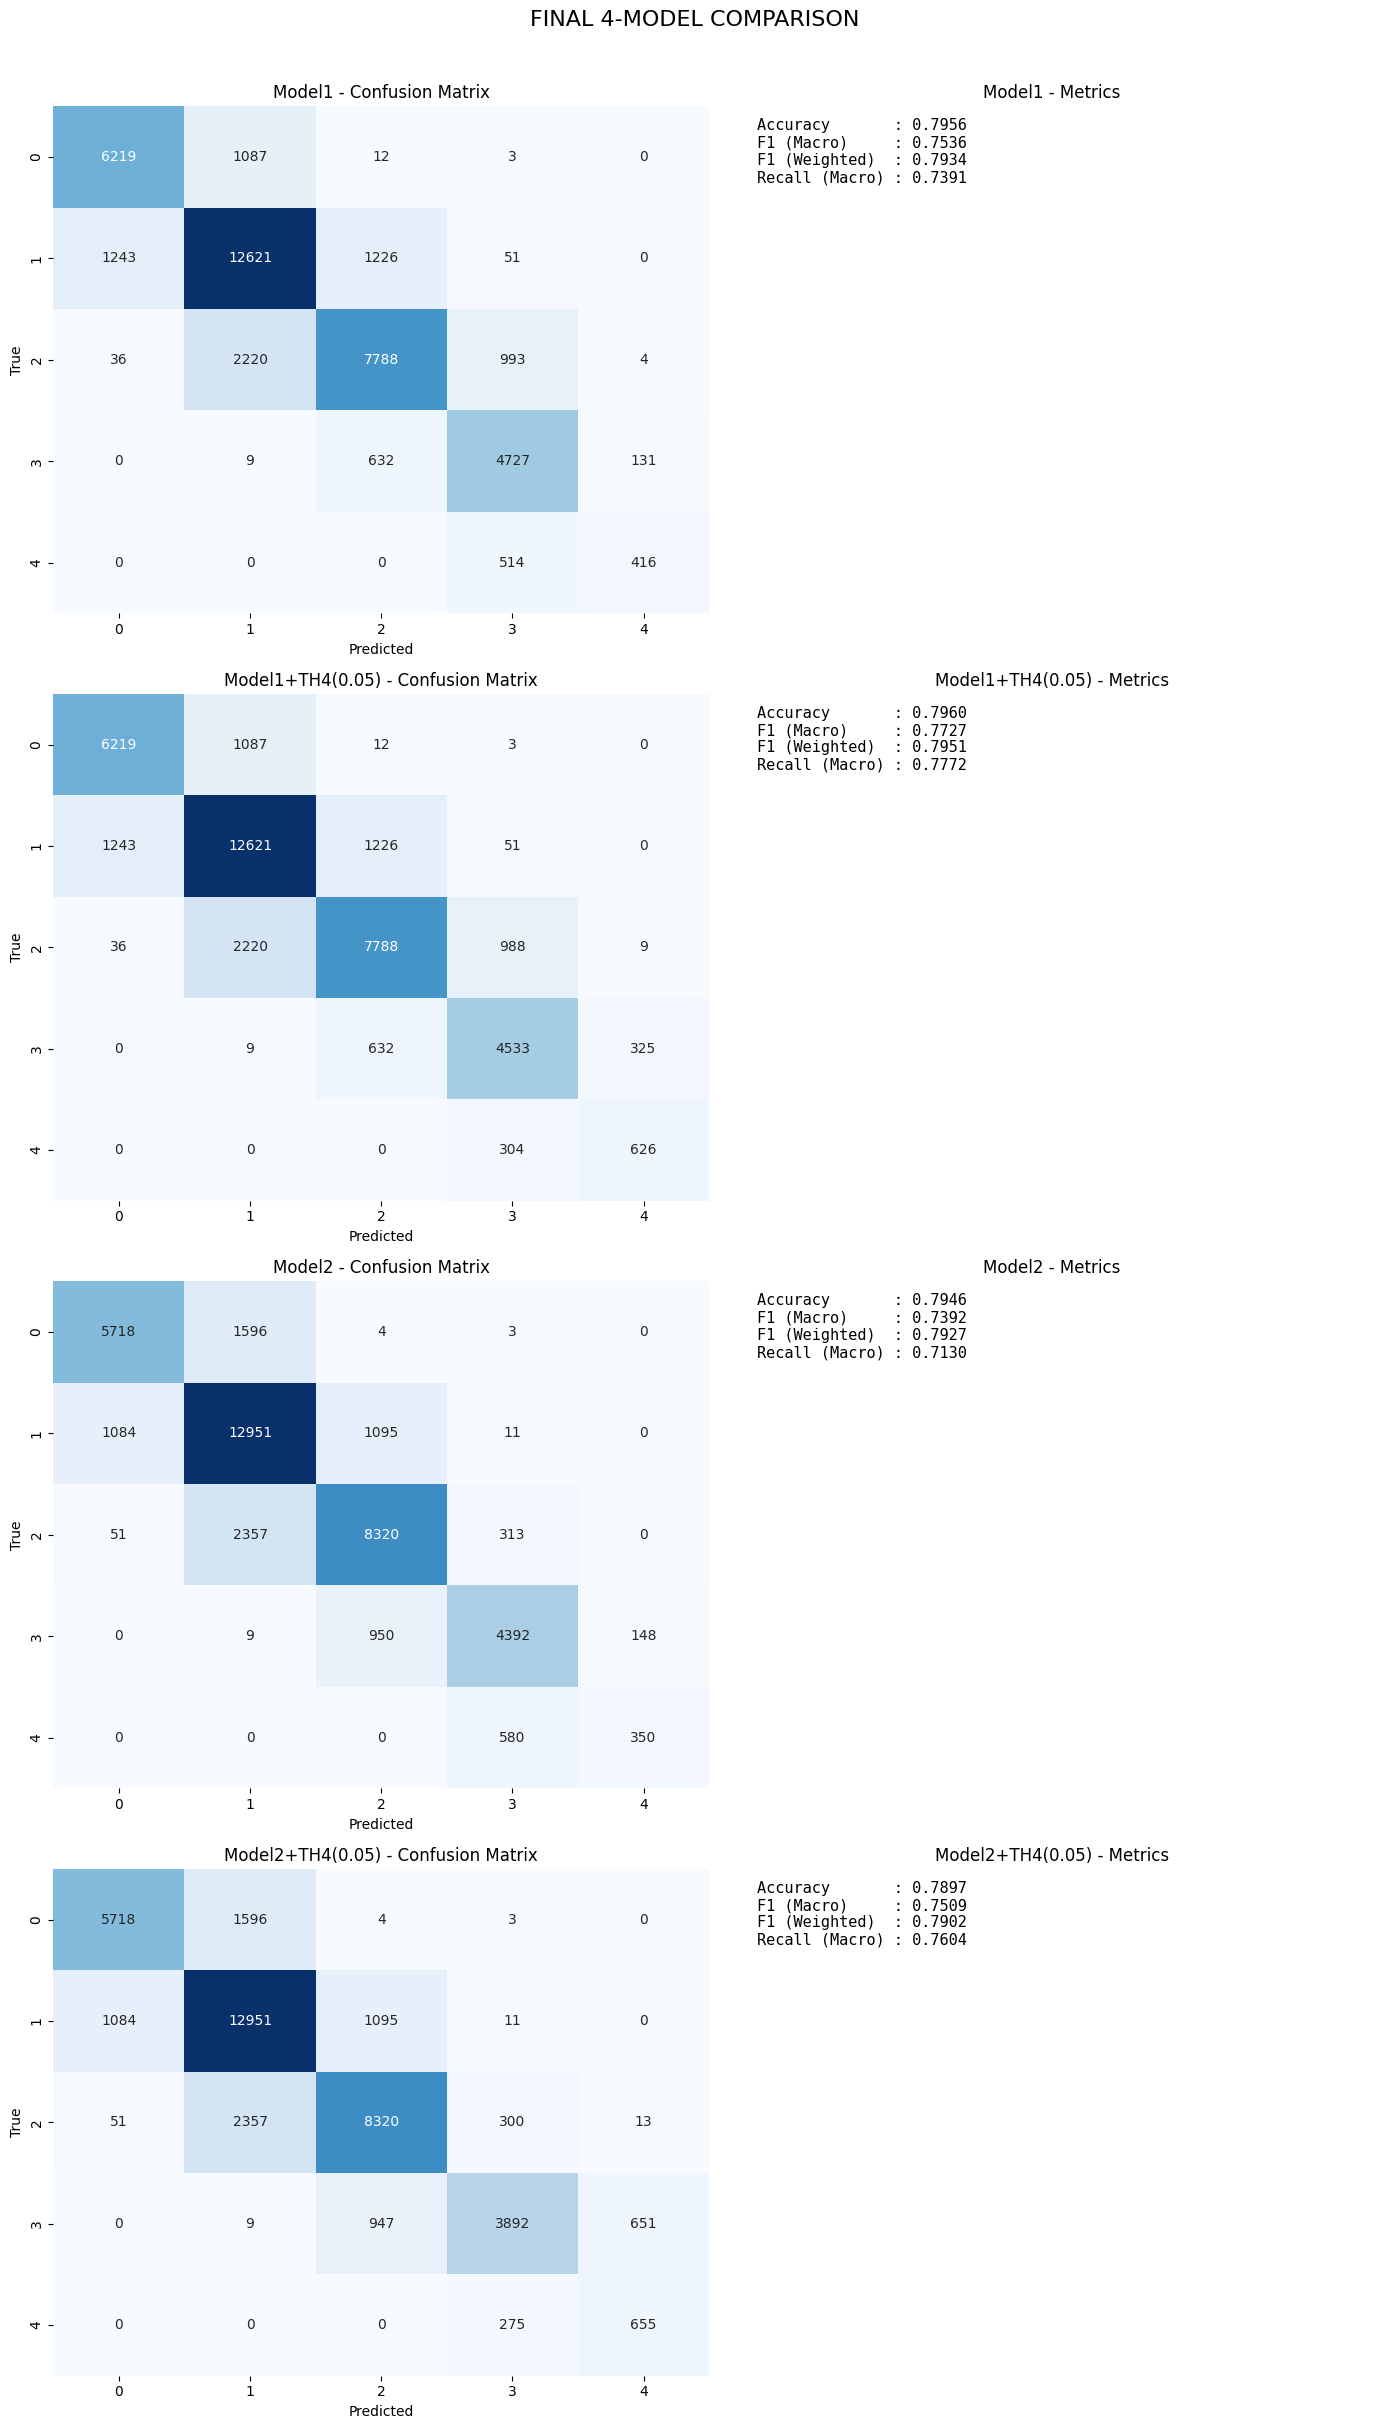

✅ Saved -> FINAL_4MODEL_VISUAL_UPDATED.png


In [20]:
# =========================================================
# FINAL 4-MODEL VISUALIZATION (TH 포함 완전 비교)
# =========================================================

def plot_confusion(y_true, y_pred, ax, title):
    labels = np.unique(np.concatenate([y_true, y_pred]))
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)


def plot_metrics(y_true, y_pred, ax, title):
    acc = accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average="macro")
    f1w = f1_score(y_true, y_pred, average="weighted")
    rec = recall_score(y_true, y_pred, average="macro")
    ax.axis("off")
    ax.set_title(title)
    summary = (
        f"Accuracy       : {acc:.4f}\n"
        f"F1 (Macro)     : {f1m:.4f}\n"
        f"F1 (Weighted)  : {f1w:.4f}\n"
        f"Recall (Macro) : {rec:.4f}"
    )
    ax.text(0.05, 0.85, summary, fontsize=11, family="monospace", transform=ax.transAxes)


models_info = [
    ("Model1",              pred_m1),
    (f"Model1+TH4({TH4})", pred_m1_th),
    ("Model2",              pred_m2),
    (f"Model2+TH4({TH4})", pred_m2_th),
]

fig, axes = plt.subplots(4, 2, figsize=(14, 24))
for i, (name, preds) in enumerate(models_info):
    plot_confusion(y_test, preds, axes[i, 0], f"{name} - Confusion Matrix")
    plot_metrics(y_test, preds, axes[i, 1],   f"{name} - Metrics")

plt.suptitle("FINAL 4-MODEL COMPARISON", fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig("FINAL_4MODEL_VISUAL_UPDATED.png", dpi=220, bbox_inches="tight")
plt.show()
print("✅ Saved -> FINAL_4MODEL_VISUAL_UPDATED.png")

---
## 유틸 함수 및 개별 상품 예측 리포트

In [21]:
# ==========================================
# 공통 유틸 함수
# ==========================================
def build_features(df: pd.DataFrame) -> pd.DataFrame:
    """학습 시 사용한 파생변수를 생성."""
    df = df.copy()
    if 'release_price' in df.columns:
        df['log_release_price'] = np.log1p(df['release_price'])
    if 'google_trend_release' in df.columns:
        df['log_google_trend_release'] = np.log1p(df['google_trend_release'])
    if 'google_trend_n_day' in df.columns:
        df['log_google_trend_n_day'] = np.log1p(df['google_trend_n_day'])
    if 'google_trend_release' in df.columns and 'google_trend_n_day' in df.columns:
        df['trend_retention'] = df['google_trend_n_day'] / (df['google_trend_release'] + 1)
    if 'hist_avg_premium' in df.columns and f'recent_avg_premium_{CONFIG["rolling_n"]}' not in df.columns:
        df[f'recent_avg_premium_{CONFIG["rolling_n"]}'] = df['hist_avg_premium']
    return df


def make_model_input(df: pd.DataFrame, selected_features: list) -> pd.DataFrame:
    """selected_features에 맞춰 입력 스키마 맞추기 (누락 컬럼 0 채움)."""
    df = df.copy()
    for c in selected_features:
        if c not in df.columns:
            df[c] = 0
    return df[selected_features]


def predict_one_model(df_feat: pd.DataFrame, model, selected_features: list):
    X = make_model_input(df_feat, selected_features)
    pred_label = int(model.predict(X)[0])
    proba = model.predict_proba(X)[0]
    confidence = float(np.max(proba))
    return pred_label, proba, confidence


label_guide = {
    0: "📉 [하락 추정] 이후 가격이 하락할 것으로 예측됩니다. (구매 보류 추천)",
    1: "➖ [안정/보합] 이후 가격 변동폭이 적을 것으로 예측됩니다.",
    2: "📈 [상승 예상] 이후 가격이 완만하게 상승할 것으로 예측됩니다.",
    3: "🚀 [급상승 예상] 인기 급증으로, 가격이 급격하게 상승할 것으로 보입니다. (선점 추천)",
    4: "🔥 [폭등 확정] 매우 높은 프리미엄 유지가 예상됩니다."
}


def predict_compare_report(
    df, product_id, model1, selected_features_m1, name1,
    model2, selected_features_m2, name2, label_guide, th4=0.10, show_proba=True
):
    df_feat = build_features(df)
    pred1, proba1, conf1 = predict_one_model(df_feat, model1, selected_features_m1)
    pred2, proba2, conf2 = predict_one_model(df_feat, model2, selected_features_m2)

    pred1_th = 4 if proba1[4] >= th4 else pred1
    pred2_th = 4 if proba2[4] >= th4 else pred2
    conf1_th = proba1[4] if pred1_th == 4 else conf1
    conf2_th = proba2[4] if pred2_th == 4 else conf2

    print("\n" + "=" * 70)
    print(f"👟 [상품 ID: {product_id}] AI 예측 비교 리포트")
    print("=" * 70)

    for label, pred, conf, proba, nm in [
        (name1,              pred1,    conf1,    proba1, name1),
        (f"{name1}+TH4",     pred1_th, conf1_th, proba1, f"{name1}+TH4({th4})"),
        (name2,              pred2,    conf2,    proba2, name2),
        (f"{name2}+TH4",     pred2_th, conf2_th, proba2, f"{name2}+TH4({th4})"),
    ]:
        print(f"\n[{nm}]")
        print(f" ▶ 예측 라벨: {pred}")
        print(f" ▶ 진단: {label_guide.get(pred, '분석 불가')}")
        print(f" ▶ 확신도: {conf*100:.2f}%")
        if show_proba:
            print(f" ▶ 클래스별 확률: {np.round(proba, 4)}")

    print("\n[비교 요약]")
    print(f" ▶ (원본) Model1={pred1} vs Model2={pred2} → {'✅ 동일' if pred1==pred2 else '⚠️ 다름'}")
    print(f" ▶ (TH4)  Model1+TH4={pred1_th} vs Model2+TH4={pred2_th} → {'✅ 동일' if pred1_th==pred2_th else '⚠️ 다름'}")
    print("=" * 70)


selected_features_m1 = list(X_train.columns)
selected_features_m2 = list(X_train_final.columns)
model1, model2 = xgb_base, xgb_final

print("✅ 유틸 함수 및 설정 완료")

✅ 유틸 함수 및 설정 완료


In [22]:
# [상품 1] 예측
new_shoes_data_1 = {
    'product_id': [791202], 'release_price': [289000], 'is_collaboration': [0],
    'google_trend_release': [71], 'google_trend_n_day': [69],
    'days_since_release': [2], 'hist_avg_premium': [0.038],
    'rolling_price_std': [4500], 'trade_velocity': [3],
    'size': [275], 'golden_size': [1],
    'color_white': [0], 'color_black': [1], 'color_grey': [0],
    'color_brown': [0], 'color_pink': [0], 'color_blue': [0],
    'color_navy': [0], 'color_green': [0], 'color_red': [0],
    'color_orange': [0], 'color_yellow': [0]
}
predict_compare_report(
    df=pd.DataFrame(new_shoes_data_1),
    product_id=791202,
    model1=model1, selected_features_m1=selected_features_m1, name1="Model 1 (Baseline)",
    model2=model2, selected_features_m2=selected_features_m2, name2="Model 2 (Refined)",
    label_guide=label_guide, th4=TH4, show_proba=True
)

# [상품 2] 예측
new_shoes_data_2 = {
    'product_id': [783522], 'release_price': [169000], 'is_collaboration': [0],
    'google_trend_release': [75], 'google_trend_n_day': [69],
    'days_since_release': [66], 'hist_avg_premium': [1.50],
    'rolling_price_std': [8500], 'trade_velocity': [2],
    'size': [270], 'golden_size': [1],
    'color_white': [0], 'color_black': [1], 'color_grey': [0],
    'color_brown': [0], 'color_pink': [0], 'color_blue': [0],
    'color_navy': [0], 'color_green': [0], 'color_red': [0],
    'color_orange': [0], 'color_yellow': [0]
}
predict_compare_report(
    df=pd.DataFrame(new_shoes_data_2),
    product_id=783522,
    model1=model1, selected_features_m1=selected_features_m1, name1="Model 1 (Baseline)",
    model2=model2, selected_features_m2=selected_features_m2, name2="Model 2 (Refined)",
    label_guide=label_guide, th4=TH4, show_proba=True
)


👟 [상품 ID: 791202] AI 예측 비교 리포트

[Model 1 (Baseline)]
 ▶ 예측 라벨: 1
 ▶ 진단: ➖ [안정/보합] 이후 가격 변동폭이 적을 것으로 예측됩니다.
 ▶ 확신도: 60.39%
 ▶ 클래스별 확률: [0.0013 0.6039 0.3846 0.0102 0.    ]

[Model 1 (Baseline)+TH4(0.05)]
 ▶ 예측 라벨: 1
 ▶ 진단: ➖ [안정/보합] 이후 가격 변동폭이 적을 것으로 예측됩니다.
 ▶ 확신도: 60.39%
 ▶ 클래스별 확률: [0.0013 0.6039 0.3846 0.0102 0.    ]

[Model 2 (Refined)]
 ▶ 예측 라벨: 2
 ▶ 진단: 📈 [상승 예상] 이후 가격이 완만하게 상승할 것으로 예측됩니다.
 ▶ 확신도: 64.76%
 ▶ 클래스별 확률: [0.0015 0.3317 0.6476 0.0192 0.    ]

[Model 2 (Refined)+TH4(0.05)]
 ▶ 예측 라벨: 2
 ▶ 진단: 📈 [상승 예상] 이후 가격이 완만하게 상승할 것으로 예측됩니다.
 ▶ 확신도: 64.76%
 ▶ 클래스별 확률: [0.0015 0.3317 0.6476 0.0192 0.    ]

[비교 요약]
 ▶ (원본) Model1=1 vs Model2=2 → ⚠️ 다름
 ▶ (TH4)  Model1+TH4=1 vs Model2+TH4=2 → ⚠️ 다름

👟 [상품 ID: 783522] AI 예측 비교 리포트

[Model 1 (Baseline)]
 ▶ 예측 라벨: 3
 ▶ 진단: 🚀 [급상승 예상] 인기 급증으로, 가격이 급격하게 상승할 것으로 보입니다. (선점 추천)
 ▶ 확신도: 99.70%
 ▶ 클래스별 확률: [0.    0.    0.003 0.997 0.   ]

[Model 1 (Baseline)+TH4(0.05)]
 ▶ 예측 라벨: 3
 ▶ 진단: 🚀 [급상승 예상] 인기 급증으로, 가격이 급격하게 상승할 것으로 보입니다. (선점 추천)
 ▶ 확신도: 

---
## 최종 예측 리포트 생성 (Test set 기준 CSV)

In [23]:
def build_report(
    test_df_raw, X_test_full, X_test_refined, y_true, model1, model2, th4
) -> pd.DataFrame:
    proba1 = model1.predict_proba(X_test_full)
    proba2 = model2.predict_proba(X_test_refined)

    pred1    = np.argmax(proba1, axis=1)
    pred2    = np.argmax(proba2, axis=1)
    pred1_th = np.where(proba1[:, 4] >= th4, 4, pred1)
    pred2_th = np.where(proba2[:, 4] >= th4, 4, pred2)

    conf1    = proba1.max(axis=1)
    conf2    = proba2.max(axis=1)
    conf1_th = np.where(pred1_th == 4, proba1[:, 4], conf1)
    conf2_th = np.where(pred2_th == 4, proba2[:, 4], conf2)

    rep = pd.DataFrame({
        'product_id'           : test_df_raw['product_id'].values,
        'trade_date'           : test_df_raw['trade_date'].values,
        'size'                 : test_df_raw.get('size', pd.Series([np.nan]*len(test_df_raw))).values,
        'true_label'           : y_true.values,
        'm1_pred'              : pred1,
        'm1_conf'              : conf1,
        f'm1_pred_th4_{th4}'   : pred1_th,
        f'm1_conf_th4_{th4}'   : conf1_th,
        'm2_pred'              : pred2,
        'm2_conf'              : conf2,
        f'm2_pred_th4_{th4}'   : pred2_th,
        f'm2_conf_th4_{th4}'   : conf2_th,
    })

    for k in range(proba1.shape[1]):
        rep[f'm1_p{k}'] = proba1[:, k]
        rep[f'm2_p{k}'] = proba2[:, k]

    rep['m1_diag']            = rep['m1_pred'].map(label_guide)
    rep['m2_diag']            = rep['m2_pred'].map(label_guide)
    rep[f'm1_diag_th4_{th4}'] = rep[f'm1_pred_th4_{th4}'].map(label_guide)
    rep[f'm2_diag_th4_{th4}'] = rep[f'm2_pred_th4_{th4}'].map(label_guide)

    return rep


test_df_raw = df_clean.iloc[test_idx].copy().reset_index(drop=True)
report_df = build_report(
    test_df_raw    = test_df_raw,
    X_test_full    = X_test.reset_index(drop=True),
    X_test_refined = X_test_final.reset_index(drop=True),
    y_true         = y_test.reset_index(drop=True),
    model1         = xgb_base,
    model2         = xgb_final,
    th4            = TH4,
)

display(report_df.head(10))

out_csv = '07_prediction_report_testset.csv'
report_df.to_csv(out_csv, index=False, encoding='utf-8-sig')
print(f'✅ Saved -> {out_csv} (rows={len(report_df):,})')

,product_id,trade_date,size,true_label,m1_pred,m1_conf,m1_pred_th4_0.05,m1_conf_th4_0.05,m2_pred,m2_conf,...,m1_p2,m2_p2,m1_p3,m2_p3,m1_p4,m2_p4,m1_diag,m2_diag,m1_diag_th4_0.05,m2_diag_th4_0.05
0,36,2020-09-16,275,1,3,0.460316,3,0.460316,3,0.542376,...,0.325641,0.312789,0.460316,0.542376,0.000329,0.000688,"🚀 [급상승 예상] 인기 급증으로, 가격이 급격하게 상승할 것으로 보입니다. (선점...","🚀 [급상승 예상] 인기 급증으로, 가격이 급격하게 상승할 것으로 보입니다. (선점...","🚀 [급상승 예상] 인기 급증으로, 가격이 급격하게 상승할 것으로 보입니다. (선점...","🚀 [급상승 예상] 인기 급증으로, 가격이 급격하게 상승할 것으로 보입니다. (선점..."
1,36,2020-09-17,280,1,3,0.495160,3,0.495160,3,0.556148,...,0.294655,0.253941,0.495160,0.556148,0.001152,0.000877,"🚀 [급상승 예상] 인기 급증으로, 가격이 급격하게 상승할 것으로 보입니다. (선점...","🚀 [급상승 예상] 인기 급증으로, 가격이 급격하게 상승할 것으로 보입니다. (선점...","🚀 [급상승 예상] 인기 급증으로, 가격이 급격하게 상승할 것으로 보입니다. (선점...","🚀 [급상승 예상] 인기 급증으로, 가격이 급격하게 상승할 것으로 보입니다. (선점..."
2,36,2020-09-19,265,1,1,0.875750,1,0.875750,1,0.921558,...,0.004965,0.014363,0.000055,0.000067,0.000017,0.000067,➖ [안정/보합] 이후 가격 변동폭이 적을 것으로 예측됩니다.,➖ [안정/보합] 이후 가격 변동폭이 적을 것으로 예측됩니다.,➖ [안정/보합] 이후 가격 변동폭이 적을 것으로 예측됩니다.,➖ [안정/보합] 이후 가격 변동폭이 적을 것으로 예측됩니다.
3,36,2020-09-20,265,1,1,0.898311,1,0.898311,1,0.929268,...,0.006003,0.016446,0.000057,0.000055,0.000041,0.000064,➖ [안정/보합] 이후 가격 변동폭이 적을 것으로 예측됩니다.,➖ [안정/보합] 이후 가격 변동폭이 적을 것으로 예측됩니다.,➖ [안정/보합] 이후 가격 변동폭이 적을 것으로 예측됩니다.,➖ [안정/보합] 이후 가격 변동폭이 적을 것으로 예측됩니다.
4,36,2020-09-25,285,0,1,0.772788,1,0.772788,1,0.905984,...,0.011840,0.018247,0.000051,0.000228,0.000046,0.000062,➖ [안정/보합] 이후 가격 변동폭이 적을 것으로 예측됩니다.,➖ [안정/보합] 이후 가격 변동폭이 적을 것으로 예측됩니다.,➖ [안정/보합] 이후 가격 변동폭이 적을 것으로 예측됩니다.,➖ [안정/보합] 이후 가격 변동폭이 적을 것으로 예측됩니다.
5,36,2020-09-25,260,0,1,0.697655,1,0.697655,1,0.656228,...,0.006957,0.015591,0.000061,0.000088,0.000021,0.000064,➖ [안정/보합] 이후 가격 변동폭이 적을 것으로 예측됩니다.,➖ [안정/보합] 이후 가격 변동폭이 적을 것으로 예측됩니다.,➖ [안정/보합] 이후 가격 변동폭이 적을 것으로 예측됩니다.,➖ [안정/보합] 이후 가격 변동폭이 적을 것으로 예측됩니다.
6,36,2020-09-25,260,0,0,0.673184,0,0.673184,0,0.650127,...,0.006024,0.007038,0.000061,0.000036,0.000024,0.000055,📉 [하락 추정] 이후 가격이 하락할 것으로 예측됩니다. (구매 보류 추천),📉 [하락 추정] 이후 가격이 하락할 것으로 예측됩니다. (구매 보류 추천),📉 [하락 추정] 이후 가격이 하락할 것으로 예측됩니다. (구매 보류 추천),📉 [하락 추정] 이후 가격이 하락할 것으로 예측됩니다. (구매 보류 추천)
7,36,2020-09-26,270,1,0,0.818929,0,0.818929,0,0.863836,...,0.003183,0.001032,0.000042,0.000022,0.000031,0.000038,📉 [하락 추정] 이후 가격이 하락할 것으로 예측됩니다. (구매 보류 추천),📉 [하락 추정] 이후 가격이 하락할 것으로 예측됩니다. (구매 보류 추천),📉 [하락 추정] 이후 가격이 하락할 것으로 예측됩니다. (구매 보류 추천),📉 [하락 추정] 이후 가격이 하락할 것으로 예측됩니다. (구매 보류 추천)
8,36,2020-10-01,280,1,0,0.823314,0,0.823314,0,0.903163,...,0.001686,0.000478,0.000032,0.000016,0.000018,0.000029,📉 [하락 추정] 이후 가격이 하락할 것으로 예측됩니다. (구매 보류 추천),📉 [하락 추정] 이후 가격이 하락할 것으로 예측됩니다. (구매 보류 추천),📉 [하락 추정] 이후 가격이 하락할 것으로 예측됩니다. (구매 보류 추천),📉 [하락 추정] 이후 가격이 하락할 것으로 예측됩니다. (구매 보류 추천)
9,36,2020-10-02,270,1,0,0.682229,0,0.682229,0,0.753109,...,0.004280,0.002534,0.000045,0.000027,0.000032,0.000030,📉 [하락 추정] 이후 가격이 하락할 것으로 예측됩니다. (구매 보류 추천),📉 [하락 추정] 이후 가격이 하락할 것으로 예측됩니다. (구매 보류 추천),📉 [하락 추정] 이후 가격이 하락할 것으로 예측됩니다. (구매 보류 추천),📉 [하락 추정] 이후 가격이 하락할 것으로 예측됩니다. (구매 보류 추천)


✅ Saved -> 07_prediction_report_testset.csv (rows=39,932)
